In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
f1_score,classification_report,confusion_matrix,roc_curve,auc)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


Original Shape: (128799, 67)
Clean Shape: (92035, 67)

Label Mapping
0 : Brute_Force
1 : HTTP_DDoS
2 : ICMP_Flood
3 : Normal
4 : Port_Scan
5 : Web_Crwling

Features after Variance Threshold: 66

Original Features : 66
Reduced Features  : 21
Principal Components : 21
Explained Variance : 0.9558892834618852


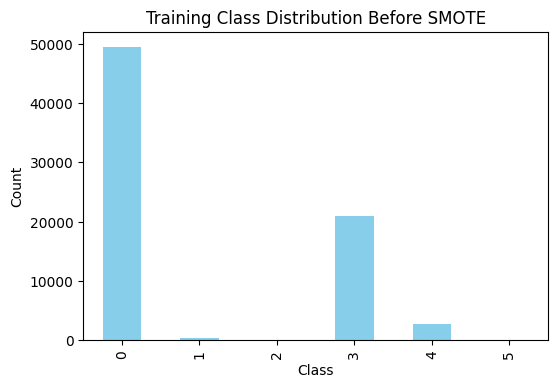

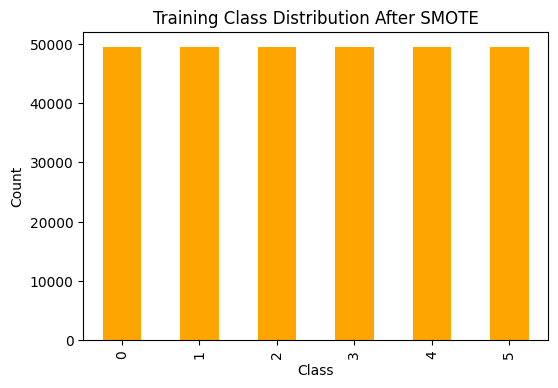

In [ ]:
df = pd.read_csv("MSCAD.csv")

print("Original Shape:", df.shape)

df = df.drop_duplicates().dropna()

print("Clean Shape:", df.shape)


le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])

print("\nLabel Mapping")
for i, c in enumerate(le.classes_):
    print(f"{i} : {c}")



X = df.drop("Label", axis=1)
y = df["Label"]



vt = VarianceThreshold(threshold=0)
X = vt.fit_transform(X)

print("\nFeatures after Variance Threshold:", X.shape[1])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("\nOriginal Features :", X.shape[1])
print("Reduced Features  :", X_pca.shape[1])
print("Principal Components :", pca.n_components_)
print("Explained Variance :", pca.explained_variance_ratio_.sum())

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


plt.figure(figsize=(6,4))

pd.Series(y_train).value_counts().sort_index().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Training Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()


sm = SMOTE(
    random_state=42,
    k_neighbors=1
)

X_train, y_train = sm.fit_resample(
    X_train,
    y_train
)


plt.figure(figsize=(6,4))

pd.Series(y_train).value_counts().sort_index().plot(
    kind="bar",
    color="orange"
)

plt.title("Training Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
model=Sequential([
Dense(128,activation='relu',input_shape=(X_train.shape[1],)),
BatchNormalization(),
Dropout(0.3),
Dense(64,activation='relu'),
BatchNormalization(),
Dropout(0.3),
Dense(32,activation='relu'),
BatchNormalization(),
Dropout(0.2),
Dense(len(np.unique(y_train)),activation='softmax')
])

model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,246 (55.65 KB)

 Trainable params: 13,798 (53.90 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=model.fit(
X_train,y_train,
epochs=50,
batch_size=64,
validation_split=0.2,
callbacks=[early],
verbose=1)


Epoch 1/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9231 - loss: 0.2344 - val_accuracy: 0.1547 - val_loss: 6.0927
Epoch 2/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9489 - loss: 0.1580 - val_accuracy: 0.1574 - val_loss: 6.3651
Epoch 3/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9546 - loss: 0.1414 - val_accuracy: 0.1579 - val_loss: 6.5431
Epoch 4/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9579 - loss: 0.1316 - val_accuracy: 0.1589 - val_loss: 5.9596
Epoch 5/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9595 - loss: 0.1260 - val_accuracy: 0.1599 - val_loss: 5.9125
Epoch 6/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9613 - loss: 0.1213 - val_accuracy: 0.1619 - val_loss: 5.4519
Epoch 7/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9619 - loss: 0.1193 - val_accuracy: 0.1597 - val_loss: 5.5043
Epoch 8/50
3722/3722 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9628 - loss: 0

In [ ]:
from sklearn.metrics import matthews_corrcoef
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print("Test Accuracy:",acc)

y_prob=model.predict(X_test)
y_pred=np.argmax(y_prob,axis=1)
mcc = matthews_corrcoef(y_test, y_pred)

print("Matthews Correlation Coefficient (MCC):", mcc)
print("\nAccuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred,average='weighted'))
print("Recall:",recall_score(y_test,y_pred,average='weighted'))
print("F1:",f1_score(y_test,y_pred,average='weighted'))

print("\nClassification Report")
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
print(cm)


Test Accuracy: 0.7939913868904114
576/576 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Matthews Correlation Coefficient (MCC): 0.6889944916520448

Accuracy: 0.7939914163090128
Precision: 0.9274662867955387
Recall: 0.7939914163090128
F1: 0.8339069178922376

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.71      0.83     12404
           1       0.88      0.89      0.88        88
           2       1.00      0.56      0.71         9
           3       0.85      0.98      0.91      5242
           4       0.17      0.89      0.28       658
           5       0.00      0.00      0.00         6

    accuracy                           0.79     18407
   macro avg       0.65      0.67      0.60     18407
weighted avg       0.93      0.79      0.83     18407

[[8792    7    0  800 2805    0]
 [   0   78    0    5    5    0]
 [   0    0    5    4    0    0]
 [   2    1    0 5155   84    0]
 [   0    2    0   71  585    0]
 [   0    1    0    5    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m